# Day 4: Unsupervised Learning & Model Tuning

### 1. 🚀 Setup and Imports

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Unsupervised Imports
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, load_breast_cancer

# Tuning Imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

---

### 2. 🕵️ Part A: Unsupervised Learning (No 'y' Target)

#### 2.1. Model 1: `KMeans` Clustering

**Concept:** Finds `k` cluster centers and assigns each data point to the nearest one.

**Task:** Create synthetic data.
```python
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=0)
```
(*We have `y` but will *not* use it for training. We'll only use it at the end to see if the model found the *real* clusters*).

In [3]:
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=0)

**Task:** Use Matplotlib to `plt.scatter(X[:, 0], X[:, 1])` to see the unlabeled data.

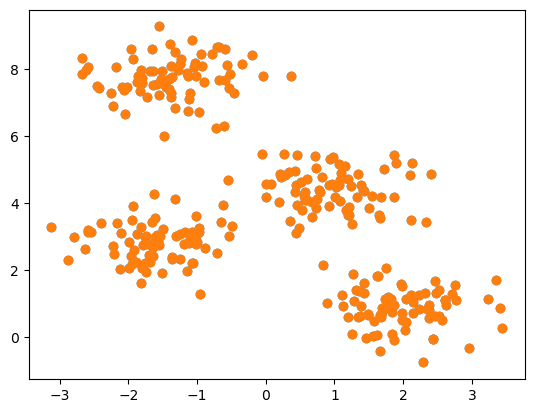

In [5]:
plt.scatter(X[: , 0], X[: , 1])
plt.show()

**Task:** Preprocessing. `KMeans` is distance-based, so we must scale.
```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Task:** Finding `k` (The Elbow Method).
1. Create an empty list `inertia_scores = []`
2. Loop `k` from 1 to 10.
3. Inside the loop:
    - `kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)`
    - `kmeans.fit(X_scaled)`
    - Append `kmeans.inertia_` to your list.
4. Plot `k` (x-axis) vs. `inertia_scores` (y-axis). The "elbow" in the graph is the best `k`.

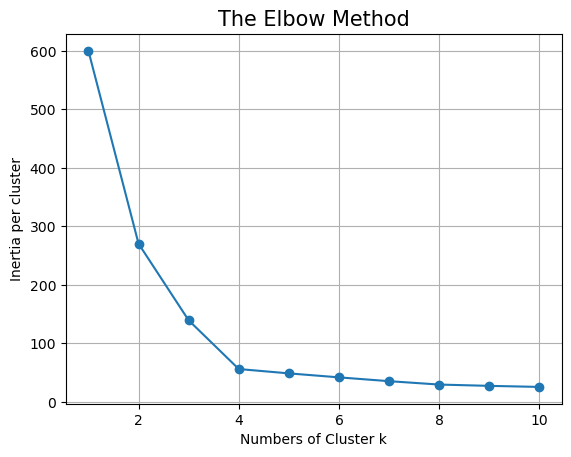

In [ ]:
inertia_scores = []
k = range(1,11)
for i in k:
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia_scores.append(kmeans.inertia_)

plt.plot(k,inertia_scores, marker = 'o')
plt.title("The Elbow Method",size = 15)
plt.xlabel("Numbers of Cluster k")
plt.ylabel("Inertia per cluster")
plt.grid()
plt.show()

**Task:** Running the Final Model.
1. Choose the best `k` from your plot (it should be 4).
2. `kmeans_final = KMeans(n_clusters=4, n_init=10, random_state=42)`
3. `kmeans_final.fit(X_scaled)`
4. Get cluster labels: `labels = kmeans_final.labels_`
5. **Visualize Results:** `plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')`
6. Plot the cluster centers: `centers = kmeans_final.cluster_centers_`
7. `plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')`

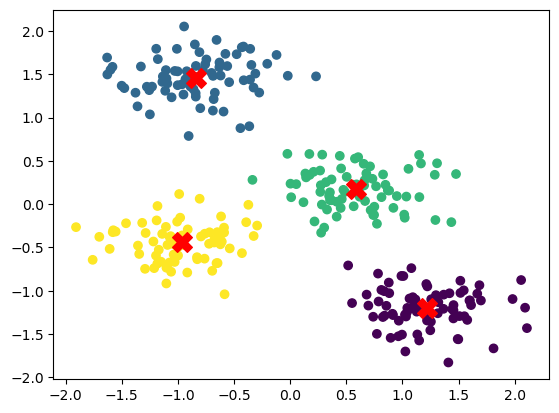

In [15]:
kmeans_final = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans_final.fit(X_scaled)
labels = kmeans_final.labels_

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
centers = kmeans_final.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')
plt.show()

#### 2.2. Model 2: `PCA` (Dimensionality Reduction)

**Concept:** "Squishes" many features (e.g., 30) down to a few (e.g., 2) while keeping as much of the original "variance" (information) as possible. Used for visualization and speeding up models.

**Task:** Load the Breast Cancer dataset. It has 30 features.
```python
data = load_breast_cancer()
X = data.data
y = data.target
```

In [16]:
data = load_breast_cancer()
X = data.data
y = data.target

**Task:** Preprocessing. `PCA` is *extremely* sensitive to scale. Scaling is mandatory.
`X_scaled = StandardScaler().fit_transform(X)`

In [17]:
X_scaled = StandardScaler().fit_transform(X)

**Task:** Running PCA.
1. Create an instance to squish to 2 components: `pca = PCA(n_components=2)`
2. Fit and transform: `X_pca = pca.fit_transform(X_scaled)`
3. Check the shape: `X_scaled.shape` vs. `X_pca.shape`.
4. Check explained variance: `pca.explained_variance_ratio_`. This shows how much info each component kept.

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [19]:
X_scaled.shape

(569, 30)

In [20]:
X_pca.shape

(569, 2)

**Task:** Visualize Results.
1. Create a DataFrame from `X_pca`: `df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])`
2. Add the *real* labels back: `df_pca['target'] = y`
3. Use Seaborn to plot: `sns.scatterplot(x='PC1', y='PC2', hue='target', data=df_pca)`
4. (You have successfully visualized a 30-dimensional dataset in 2D!)

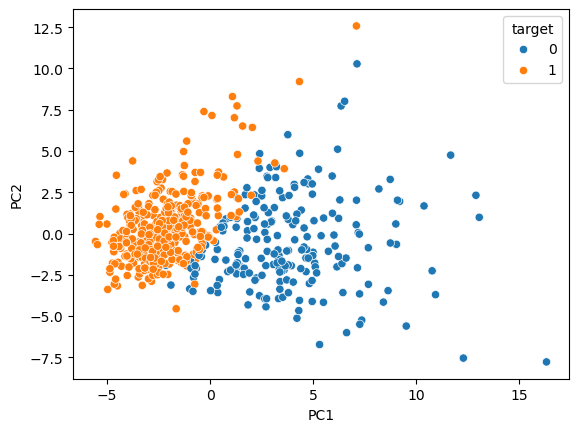

In [21]:
df_pca = pd.DataFrame(X_pca,columns=['PC1','PC2'])
df_pca['target'] = y
sns.scatterplot(x='PC1', y='PC2', hue='target', data=df_pca)
plt.show()

---

### 3. 🔧 Part B: Model Tuning & Selection (The Capstone)

**Concept:** You can build models, but how do you (a) test them properly and (b) find their *best* settings (hyperparameters)?

**Task:** Load the Breast Cancer data (`X` and `y` from Part A) and do a `train_test_split`. We will *only* use `X_train` and `y_train` for this part.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 3.1. Technique 1: `cross_val_score` (Robust Testing)

**Concept:** A single `train_test_split` is risky. Cross-validation (CV) is a better test. It splits the *training* data into `k` (e.g., 5) folds, then trains 5 times, using a different fold as the "test set" each time.

**Task:** 
1. Create a model: `model_rf_cv = RandomForestClassifier(random_state=42)`
2. Run CV: `scores = cross_val_score(model_rf_cv, X_train, y_train, cv=5, scoring='accuracy')`
3. Print results:
    - `print(f"All 5 scores: {scores}")`
    - `print(f"Mean accuracy: {scores.mean()}")`
    - `print(f"Std deviation: {scores.std()}")`
4. (This mean score is a much more reliable estimate of your model's performance).

In [23]:
model_rf_cv = RandomForestClassifier(random_state=42)
scores = cross_val_score(model_rf_cv, X_train, y_train, cv=5, scoring='accuracy')

print(f"All 5 scores: {scores}")
print(f"Mean accuracy: {scores.mean()}")
print(f"Std deviation: {scores.std()}")

All 5 scores: [0.97802198 0.94505495 0.97802198 0.95604396 0.93406593]
Mean accuracy: 0.9582417582417582
Std deviation: 0.017582417582417565


#### 3.2. Technique 2: `GridSearchCV` (Hyperparameter Tuning)

**Concept:** Automates the process of finding the best "knobs" (hyperparameters) for a model. It tries *every possible combination* you give it, using cross-validation.

**Task:** 1. Define the "Parameter Grid"
Create a dictionary of "knobs" to try for a `RandomForestClassifier`.
```python
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}
```
(*This is 3 * 3 * 3 = 27 combinations to test!*)

In [24]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

**Task:** 2. Create `GridSearchCV` instance
```python
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                         param_grid=param_grid,
                         cv=5,
                         scoring='accuracy',
                         n_jobs=-1, # uses all your CPU cores
                         verbose=2) # shows you its progress
```

In [25]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                         param_grid=param_grid,
                         cv=5,
                         scoring='accuracy',
                         n_jobs=-1, 
                         verbose=2) 

**Task:** 3. Run the search.
`grid_search.fit(X_train, y_train)`

In [26]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=2)

**Task:** 4. Get Best Results.
- Print the best parameters: `print(grid_search.best_params_)`
- Print the best score (from CV): `print(grid_search.best_score_)`

In [27]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
0.9626373626373625


**Task:** 5. Use the Best Model.
The `grid_search` object *is* now the best model, already retrained on all training data.
1. `best_model = grid_search.best_estimator_`
2. `final_predictions = best_model.predict(X_test)`
3. Print the *final* Classification Report on the `X_test` data. This is your true, final score.

In [29]:
best_model = grid_search.best_estimator_
final_predictions = best_model.predict(X_test)
print(f"Final Classification Report of Best Model :\n{classification_report(y_test,final_predictions)}")

Final Classification Report of Best Model :
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

